In [244]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [245]:
VIDEO_PATH = "/content/drive/MyDrive/datasets/rails1.mp4"

In [246]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [247]:
def imshow(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(3, 3), dpi=300)
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

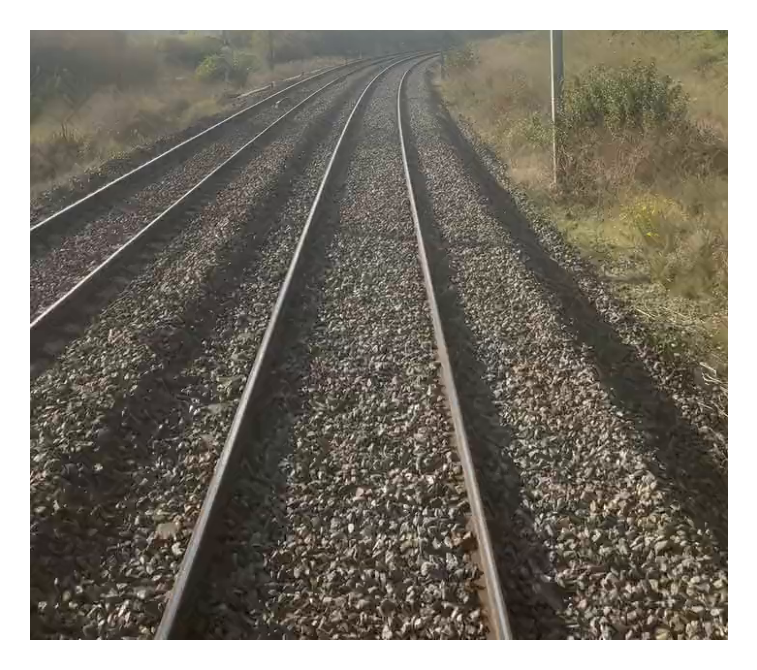

In [248]:
vc = cv2.VideoCapture(VIDEO_PATH)
_, src = vc.read()
imshow(src[650:])

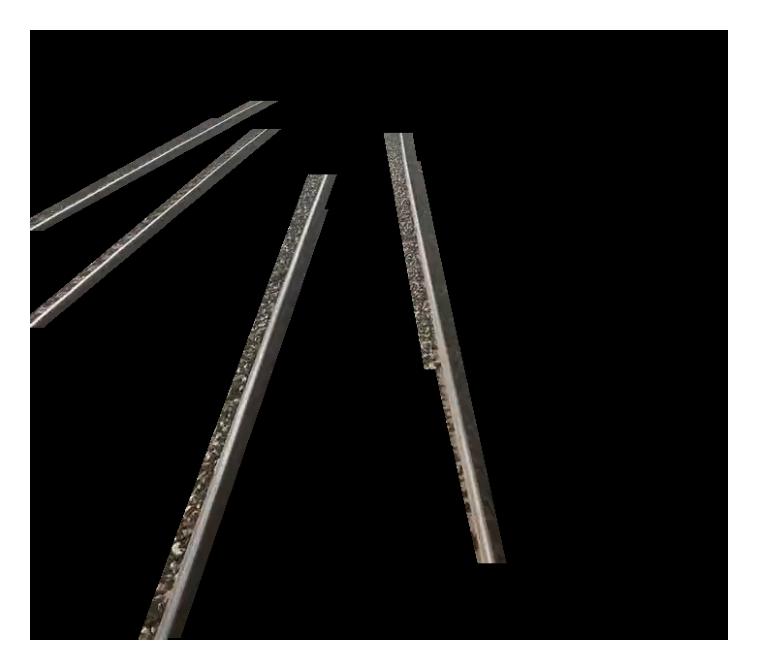

In [258]:
res = preprocess(src[650:])
imshow(res)
# imshow(cv2.bitwise_and(src[:,460:850], src[:,460:850], mask=create_mask(res, lines, 10)))

In [250]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sobelx = cv2.Sobel(gray, ddepth=cv2.CV_64F, ksize=7, dx=1, dy=0)
    old_min, old_max = img.min(), img.max()
    sobel_norm = np.uint8((img - old_min) * (255.0 / (old_max - old_min)))
    blur = cv2.GaussianBlur(sobel_norm, (7, 7), 0)
    edges = cv2.Canny(blur, 100, 200)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=125,
        minLineLength=200,
        maxLineGap=20
    )
    if lines is not None:
        return cv2.bitwise_and(img, img, mask=create_mask(img.shape[:2], lines, 15))
    else:
        return np.zeros(img.shape[:2], dtype=np.uint8)

In [251]:
def get_lines_points(x1, y1, x2, y2):
    if y1 == y2:
        return []
    if x1 == x2:
        return []
    k = (y1 - y2)/(x1 - x2)
    b = y2 - k*x2
    points = [(y1, x1)]
    step_y = 1 if y2 > y1 else -1
    for y in range(y1, y2, step_y):
        points.append((y, int((y-b)/k)))
    points.append((y2, x2))
    return points

In [257]:
def create_mask(shape, lines, area=5):
    mask = np.zeros(shape, dtype=np.uint8)
    for line in lines:
        points = get_lines_points(*line[0])
        for point in points:
            y, x = point
            left = max(x - area, 0)
            right = min(x + area, shape[1])
            mask[y, left:right] = 255
    return mask

In [253]:
def main():
    vc = cv2.VideoCapture(VIDEO_PATH)
    fps = vc.get(cv2.CAP_PROP_FPS)
    width = int(vc.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(vc.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(vc.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = cv2.VideoWriter(
        "output.mp4",
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height-650)
    )
    for i in tqdm(range(int(frame_count))):
        ret, frame = vc.read()
        if not ret:
            break
        processed_frame = preprocess(frame[650:])

        writer.write(processed_frame)

    vc.release()
    writer.release()

In [259]:
import cProfile
cProfile.run('main()', 'profile_output')  # Сохраняет результат в файл

100%|██████████| 4460/4460 [02:41<00:00, 27.59it/s]


In [261]:
import pstats
from pstats import SortKey

# Способ 1: Анализ сохранённого файла
stats = pstats.Stats('profile_output')

# Убираем пути, сортируем по общему времени и показываем топ-10
stats.strip_dirs().sort_stats(SortKey.CUMULATIVE).print_stats(20)

# Или анализируем функции, подозрительно начинающиеся с 'calculate'
stats.strip_dirs().sort_stats(SortKey.TIME).print_stats('calculate.*')

Tue Jun  9 13:26:14 2026    profile_output

         17412071 function calls (17374192 primitive calls) in 161.680 seconds

   Ordered by: cumulative time
   List reduced from 301 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
6556/6555    0.309    0.000  422.965    0.065 base_events.py:1922(_run_once)
      2/1    0.005    0.002  155.019  155.019 {built-in method builtins.exec}
     4460   13.786    0.003  114.757    0.026 4064871143.py:1(preprocess)
6562/6559    0.099    0.000   35.568    0.005 events.py:86(_run)
     4460   26.857    0.006   26.857    0.006 {Canny}
     4460   26.493    0.006   26.493    0.006 {HoughLinesP}
     3045    7.828    0.003   16.109    0.005 1281229036.py:1(create_mask)
     3045   15.166    0.005   15.166    0.005 {bitwise_and}
     4460   15.028    0.003   15.028    0.003 {Sobel}
     4460   11.648    0.003   11.648    0.003 {GaussianBlur}
     4460   11.611    0.003   11.611    0.003 {method 'writ